In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning, ConvergenceWarning, RuntimeWarning
import numpy as np
from tqdm import tqdm

# Suppress both specific warnings
warnings.simplefilter('ignore', ValueWarning)
warnings.simplefilter('ignore', ConvergenceWarning)
warnings.simplefilter('ignore', RuntimeWarning)

## Load Data

In [3]:
selected_data = pd.read_csv('etfs_macro_large.csv')

selected_data.head()

,date,SPY,XLI,XLE,XLK,XLV,XLU,XLF,XLY,XLP,...,DDURRG3M086SBEA,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST
0,2000-02-01,-0.050622,-0.085334,0.008042,-0.063456,-0.025616,-0.017928,-0.030032,-0.132669,0.008781,...,-0.002376,0.005015,-0.000585,-0.000680,0.002320,-0.002843,-0.7,0.006184,-0.003170,-0.007322
1,2000-03-01,-0.015791,-0.056752,-0.043256,0.099907,-0.067623,-0.129583,-0.113220,-0.057327,-0.124446,...,0.004724,0.005486,-0.001198,-0.000673,-0.000606,0.000704,-4.2,-0.029803,-0.001179,0.016590
2,2000-04-01,0.092426,0.130235,0.117210,0.080559,0.086132,0.103583,0.167561,0.132281,0.036913,...,-0.003455,-0.016761,-0.001331,0.001973,0.001705,0.002106,2.1,-0.000135,0.008686,-0.005609
3,2000-05-01,-0.035753,0.014343,-0.015037,-0.096342,-0.011786,0.063406,0.009613,-0.021042,0.051661,...,0.001610,0.002287,0.001466,-0.004625,-0.006921,-0.004928,1.5,0.024727,-0.000153,-0.001897
4,2000-06-01,-0.015848,-0.004228,0.111026,-0.109789,-0.027170,-0.002196,0.022076,-0.055492,0.068900,...,-0.003220,0.010881,0.000796,0.003291,0.001150,0.006313,-4.3,-0.006503,0.008705,0.001113


<Axes: >

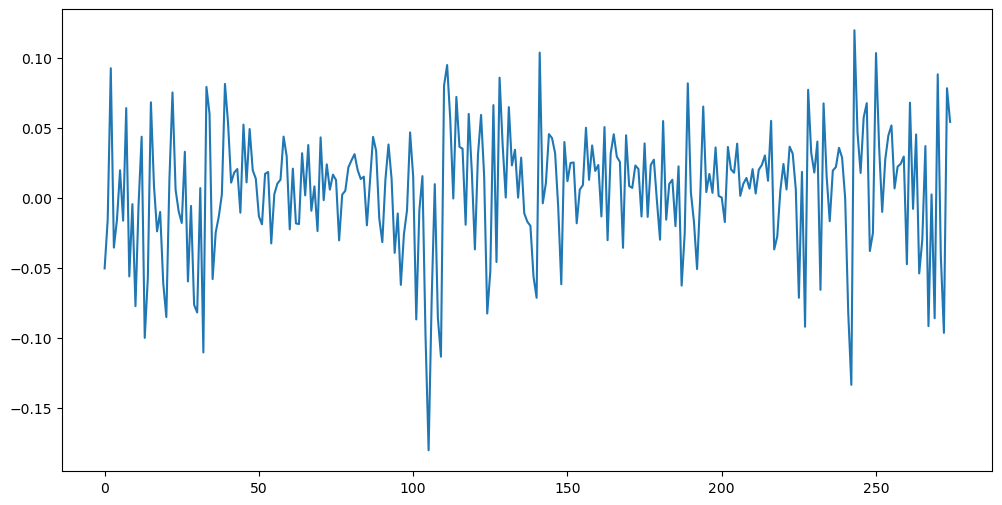

In [4]:
target = 'SPY'

selected_data[target].plot(figsize=(12, 6))

## Fit Model - Markov Switching dynamic Regression

In [5]:
reg_df = selected_data[[target]].copy()

# add first lag of the target variable as a regressor
reg_df[f'{target}_lag1'] = reg_df[target].shift(1)

# drop nan
reg_df = reg_df.dropna()

# Fit the model
mod_areturns = sm.tsa.MarkovRegression(
    reg_df[target],
    exog=reg_df.drop(columns=[target]),
    k_regimes=2,
    switching_variance=True,
)
res_areturns = mod_areturns.fit()

res_areturns.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                        Markov Switching Model Results                        
==============================================================================
Dep. Variable:                    SPY   No. Observations:                  274
Model:               MarkovRegression   Log Likelihood                 495.224
Date:                Fri, 13 Mar 2026   AIC                           -974.447
Time:                        18:02:38   BIC                           -945.542
Sample:                             0   HQIC                          -962.846
                                - 274                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0154      0.003      5.794      0.000       0.010       0.021
x1            -0.1600      0.106     -1.515      0.130      -0.367       0.047
sigma2         0.0005   8.24e-05      6.040      0.000       0.000       0.001
                             Regime 1 parameters                              
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0012      0.005     -0.234      0.815      -0.011       0.009
x1             0.0376      0.085      0.441      0.659      -0.130       0.205
sigma2         0.0032      0.000      7.358      0.000       0.002       0.004
                         Regime transition parameters                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
p[0->0]        0.9519      0.025     37.593      0.000       0.902       1.002
p[1->0]        0.0365      0.026      1.408      0.159      -0.014       0.087
==============================================================================

Warnings:
[1] Covariance matrix calculated using numerical (complex-step) differentiation.
"""

<Axes: title={'center': 'Probability of being in a low-variance regime'}>

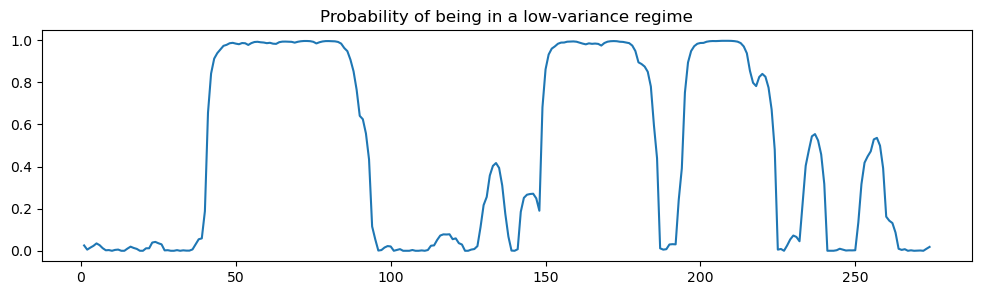

In [6]:
res_areturns.smoothed_marginal_probabilities[0].plot(
    title="Probability of being in a low-variance regime", figsize=(12, 3)
)

## Walk-Forward Forecasting: First Step

In [7]:
target = 'SPY'
fs_method = 'markov-switching-dyn-reg'
estimation_window = 12 * 7
fix_start = True
p = 1
max_p = 3

data = selected_data.copy()
data['date'] = pd.to_datetime(data['date'])
data = data.set_index('date')

step = next(iter(range(0, len(data) - estimation_window, 1)))

if fix_start or (step == 0):
    start = 0
else:
    start += 1

train_df = data.iloc[start:(estimation_window + step), :]
test_df = data.iloc[start:(estimation_window + step + 1), :]

labelled_clusters = pd.DataFrame([{"fred": target, "cluster": 1, "description": target}])
selected_columns = list(train_df.drop([target], axis=1).columns)

train_df = train_df[[target] + selected_columns]

# zscore of train data
mean = train_df.mean()
std = train_df.std()

train_df = (train_df - mean) / std

# select optimal laga
if p == -1:
    var_select_model = VAR(train_df)
    selected_p = var_select_model.select_order(maxlags=max_p)
    selected_p = selected_p.selected_orders["aic"]
    if selected_p == 0:
        selected_p = 1
else:
    selected_p = min(p, max_p)

test_df = test_df[[target] + selected_columns].iloc[(estimation_window + step - selected_p):(estimation_window + step + 1), :]

# zscore of test data
test_df = (test_df - mean) / std

# subset data into train and test
Xt_train = train_df.drop([target], axis=1)
yt_train = train_df[[target]]

Xt_test = test_df.drop([target], axis=1)
yt_test = test_df[[target]]

In [12]:
k_regimes_trials = [2, 3, 4]
regime_models_summary = []
for k_regimes in k_regimes_trials:
    mod_areturns = sm.tsa.MarkovRegression(
        yt_train,
        trend='n',
        k_regimes=k_regimes,
        switching_variance=True,
    )
    res_areturns = mod_areturns.fit()

    regime_models_summary.append({
        "k_regimes": k_regimes,
        "aic": res_areturns.aic,
        "bic": res_areturns.bic,
        "hqic": res_areturns.hqic,
    })
regime_models_summary_df = pd.DataFrame(regime_models_summary)

selected_k_regimes = int(regime_models_summary_df.sort_values('aic').reset_index(drop=True).iloc[0]['k_regimes'])

final_model_msdr = sm.tsa.MarkovRegression(
    yt_train,
    trend='c',
    k_regimes=selected_k_regimes,
    switching_variance=True,
)
final_res_msdr = final_model_msdr.fit()

In [13]:
# 1. Get the probabilities of being in each regime at the LAST training step (t)
# These are the "Filterred" or "Smoothed" probabilities at time T
current_probs = final_res_msdr.smoothed_marginal_probabilities.iloc[-1].values

# 2. Get the Transition Matrix (P)
# In statsmodels, the property is 'regime_transition'
transition_matrix = final_res_msdr.regime_transition 

# 3. Forecast the probabilities for the NEXT step (t+1)
# next_step_probs[j] = Σ (current_probs[i] * P[i,j])
next_step_probs = current_probs @ transition_matrix

# 4. Get the predicted values (the 'const') for each regime
# We use the .params object directly. 
# For MarkovRegression, these are usually 'const[0]', 'const[1]', etc.
regime_means = np.array([final_res_msdr.params[f'const[{i}]'] for i in range(selected_k_regimes)])

# 5. The One-Step Ahead Forecast (The Expected Value)
y_hat_tp1 = (next_step_probs * regime_means).sum()

## Walk-Forward Forecasting: Full Walk

In [15]:
target = 'SPY'
fs_method = 'markov-switching-dyn-reg'
estimation_window = 12 * 7
fix_start = True
p = 1
max_p = 3

data = selected_data.copy()
data['date'] = pd.to_datetime(data['date'])
data = data.set_index('date').sort_index()

# --------------------------------------------------
# ADD LAG FEATURES
# --------------------------------------------------
for lag in range(1, max_p + 1):
    data[f'{target}_lag{lag}'] = data[target].shift(lag)

data = data.dropna().copy()

# --------------------------------------------------
# HELPERS
# --------------------------------------------------
def get_latest_transition_matrix(res, k_regimes):
    """
    Robustly extract the latest transition matrix.
    """
    P = np.asarray(res.regime_transition)

    if P.ndim == 2:
        return P

    if P.ndim == 3:
        # Usually shape is (k, k, T) in statsmodels
        if P.shape[0] == k_regimes and P.shape[1] == k_regimes:
            return P[:, :, -1]
        # fallback if weird ordering
        if P.shape[-2] == k_regimes and P.shape[-1] == k_regimes:
            return P[-1, :, :]

    raise ValueError(f"Unexpected regime_transition shape: {P.shape}")


def get_next_step_probs(current_probs, transition_matrix):
    """
    Multiply current regime probs by transition matrix robustly.
    """
    current_probs = np.asarray(current_probs).reshape(-1)
    P = np.asarray(transition_matrix)

    # Default: row vector times matrix
    try:
        probs = current_probs @ P
    except Exception:
        probs = P.T @ current_probs

    probs = np.asarray(probs).reshape(-1)

    if probs.sum() > 0:
        probs = probs / probs.sum()

    return probs


def regime_specific_forecast(res, x_next, exog_cols, k_regimes):
    """
    Build regime-specific conditional means robustly.

    Handles:
    - no intercept (trend='n')
    - shared intercept ('const')
    - regime-specific intercepts ('const[0]', ...)
    - shared exog coeffs ('x1' or actual col name)
    - regime-specific exog coeffs ('x1[0]' or 'col[0]')
    """
    params = res.params.copy()

    if not isinstance(params, pd.Series):
        # try to recover names if params is ndarray
        if hasattr(res.model, "param_names"):
            params = pd.Series(params, index=res.model.param_names)
        else:
            raise ValueError("Could not recover parameter names from fitted model.")

    # make x_next a Series aligned with exog_cols
    if isinstance(x_next, pd.DataFrame):
        x_next = x_next.iloc[0]
    elif isinstance(x_next, np.ndarray):
        x_next = pd.Series(x_next, index=exog_cols)

    forecasts = []

    for i in range(k_regimes):
        mu_i = 0.0

        # -------------------------
        # intercept / constant
        # -------------------------
        for key in [f'const[{i}]', f'intercept[{i}]', 'const', 'intercept']:
            if key in params.index:
                mu_i += float(params[key])
                break

        # -------------------------
        # exogenous coefficients
        # -------------------------
        for j, col in enumerate(exog_cols):
            xval = float(x_next[col])

            # Try regime-specific keys first
            regime_keys = [
                f'{col}[{i}]',
                f'x{j+1}[{i}]'
            ]

            shared_keys = [
                col,
                f'x{j+1}'
            ]

            coef = None

            for key in regime_keys:
                if key in params.index:
                    coef = float(params[key])
                    break

            if coef is None:
                for key in shared_keys:
                    if key in params.index:
                        coef = float(params[key])
                        break

            if coef is not None:
                mu_i += coef * xval

        forecasts.append(mu_i)

    return np.array(forecasts)


# --------------------------------------------------
# MAIN LOOP
# --------------------------------------------------
predictions = []

for step in tqdm(
    range(0, len(data) - estimation_window - 1, 1),
    total=len(data) - estimation_window - 1,
    desc=f"forecasting {fs_method}: {target}"
):

    if fix_start or step == 0:
        start = 0
    else:
        start += 1

    train_end = estimation_window + step
    test_idx = train_end  # one-step-ahead row

    train_df = data.iloc[start:train_end].copy()
    test_row = data.iloc[test_idx:test_idx + 1].copy()

    # --------------------------------------------------
    # SELECT FEATURES
    # --------------------------------------------------
    lag_columns = [f'{target}_lag{i}' for i in range(1, max_p + 1)]
    selected_columns = lag_columns.copy()

    train_df = train_df[[target] + selected_columns].copy()
    test_row = test_row[[target] + selected_columns].copy()

    # --------------------------------------------------
    # ZSCORE NORMALIZATION
    # --------------------------------------------------
    mean = train_df.mean()
    std = train_df.std()

    # avoid division by zero
    std = std.replace(0, 1.0)

    train_z = (train_df - mean) / std
    test_z = (test_row - mean) / std

    # --------------------------------------------------
    # LAG ORDER SELECTION
    # --------------------------------------------------
    if p == -1:
        try:
            var_select_model = VAR(train_z[[target] + lag_columns])
            selected_orders = var_select_model.select_order(maxlags=max_p)
            selected_p = selected_orders.selected_orders.get("aic", None)

            if selected_p is None or selected_p <= 0:
                selected_p = 1
        except Exception:
            selected_p = 1
    else:
        selected_p = min(p, max_p)

    selected_lag_cols = [f'{target}_lag{i}' for i in range(1, selected_p + 1)]

    Xt_train = train_z[selected_lag_cols].copy()
    yt_train = train_z[target].copy()

    Xt_test = test_z[selected_lag_cols].copy()
    yt_test = test_row[[target]].copy()
    yt_test_zscore = test_z[[target]].copy()

    # --------------------------------------------------
    # REGIME SELECTION
    # --------------------------------------------------
    k_regimes_trials = [2, 3, 4]
    regime_models_summary = []

    for k_regimes in k_regimes_trials:
        try:
            mod_trial = sm.tsa.MarkovRegression(
                yt_train,
                exog=Xt_train,
                trend='n',
                k_regimes=k_regimes,
                switching_variance=True,
            )
            res_trial = mod_trial.fit(disp=False)

            regime_models_summary.append({
                "k_regimes": k_regimes,
                "aic": res_trial.aic,
                "bic": res_trial.bic,
                "hqic": res_trial.hqic,
            })
        except Exception:
            continue

    if len(regime_models_summary) == 0:
        # skip this window if all fits fail
        continue

    regime_models_summary_df = pd.DataFrame(regime_models_summary)
    selected_k_regimes = int(
        regime_models_summary_df.sort_values('aic').reset_index(drop=True).iloc[0]['k_regimes']
    )

    # --------------------------------------------------
    # FINAL MODEL
    # --------------------------------------------------
    try:
        final_model_msdr = sm.tsa.MarkovRegression(
            yt_train,
            exog=Xt_train,
            trend='n',
            k_regimes=selected_k_regimes,
            switching_variance=True,
        )
        final_res_msdr = final_model_msdr.fit(disp=False)
    except Exception:
        continue

    # --------------------------------------------------
    # FORECAST
    # --------------------------------------------------
    try:
        current_probs = np.asarray(
            final_res_msdr.smoothed_marginal_probabilities.iloc[-1]
        ).reshape(-1)

        transition_matrix = get_latest_transition_matrix(final_res_msdr, selected_k_regimes)
        next_step_probs = get_next_step_probs(current_probs, transition_matrix)

        regime_forecasts = regime_specific_forecast(
            final_res_msdr,
            Xt_test.iloc[0],
            selected_lag_cols,
            selected_k_regimes
        )

        ypred_zscore = float((next_step_probs * regime_forecasts).sum())
    except Exception:
        continue

    # back to original scale
    ypred = ypred_zscore * std[target] + mean[target]

    pred = pd.DataFrame([{
        "date": yt_test.index[-1],
        "prediction_zscore": ypred_zscore,
        "true_zscore": float(yt_test_zscore.iloc[-1, 0]),
        "prediction": float(ypred),
        "true": float(yt_test.iloc[-1, 0]),
        "selected_p": selected_p,
        "selected_k_regimes": selected_k_regimes,
    }])

    predictions.append(pred)

# --------------------------------------------------
# SAVE PREDICTIONS
# --------------------------------------------------
if len(predictions) == 0:
    predictions_df = pd.DataFrame(columns=[
        "prediction_zscore", "true_zscore", "prediction", "true",
        "selected_p", "selected_k_regimes"
    ])
else:
    predictions_df = pd.concat(predictions, axis=0)

predictions_df['date'] = pd.to_datetime(predictions_df['date'])
predictions_df.set_index('date', inplace=True)

forecasting markov-switching-dyn-reg: SPY:   0%|          | 0/187 [00:00<?, ?it/s]

forecasting markov-switching-dyn-reg: SPY:  30%|██▉       | 56/187 [05:41<14:59,  6.87s/it]/home/danielco/miniconda3/envs/cml-fin/lib/python3.8/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/danielco/miniconda3/envs/cml-fin/lib/python3.8/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
forecasting markov-switching-dyn-reg: SPY:  32%|███▏      | 59/187 [06:03<14:53,  6.98s/it]/home/danielco/miniconda3/envs/cml-fin/lib/python3.8/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/danielco/miniconda3/envs/cml-fin/lib/python3.8/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, 

In [16]:
predictions_df

,prediction_zscore,true_zscore,prediction,true,selected_p,selected_k_regimes
date,,,,,,
2007-05-01,0.014398,1.076227,0.001220,0.043343,1,3
2007-06-01,0.230446,0.811154,0.010301,0.033357,1,3
2007-07-01,0.092615,-0.409023,0.005195,-0.014681,1,2
2007-08-01,-0.038172,-0.840723,-0.000166,-0.031811,1,2
2007-09-01,-0.105772,0.299503,-0.003201,0.012751,1,2
...,...,...,...,...,...,...
2022-07-01,-0.005674,-2.100318,0.005082,-0.086199,1,2
2022-08-01,-0.168223,1.894953,-0.002391,0.088091,1,2
2022-09-01,0.115281,-1.065535,0.010377,-0.041658,1,2


<Axes: title={'center': 'markov-switching-dyn-reg - SPY'}, xlabel='date'>

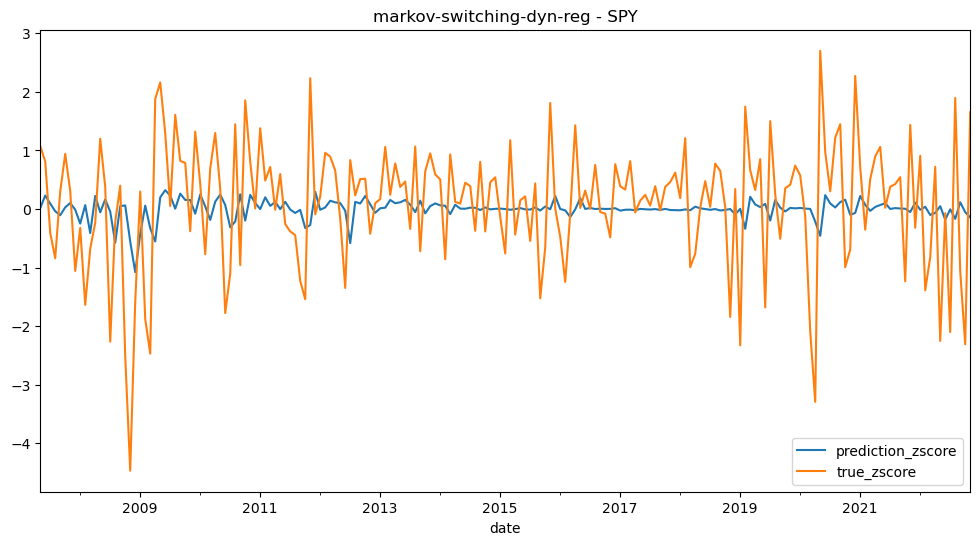

In [17]:
predictions_df[['prediction_zscore', 'true_zscore']].plot(figsize=(12, 6), title="{} - {}".format(fs_method, target))